In [ ]:
import operator
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Any, Annotated, Dict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field

In [35]:
load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile", 
                 api_key=os.getenv("API_KEY"),
                 temperature=0.1)

In [36]:
class EvaluationMetrics(BaseModel):
    feedback: str = Field(description="Feedback on the essay")
    score: int = Field(description="score for the essay on specified metrics", ge=0, le=10)

In [37]:
structured_output=model.with_structured_output(EvaluationMetrics)

In [38]:
essay="""
# Climate Change

Climate change is one of the most pressing challenges facing humanity today. It refers to long-term changes in global temperature and weather patterns, primarily caused by human activities such as burning fossil fuels, deforestation, and industrialization. These activities increase the concentration of greenhouse gases in the atmosphere, leading to global warming.

The impacts of climate change are visible across the world. Rising temperatures, melting glaciers, frequent heat waves, floods, droughts, and cyclones threaten ecosystems and human livelihoods. Agriculture, water resources, biodiversity, and public health are particularly vulnerable. Developing countries like India face greater risks due to their dependence on climate-sensitive sectors and large populations.

Addressing climate change requires collective action at the global, national, and individual levels. International agreements such as the Paris Agreement aim to limit global temperature rise and promote sustainable development. India has taken significant steps through renewable energy expansion, afforestation programs, and initiatives like Mission LiFE.

Individuals can contribute by conserving energy, reducing waste, using public transport, and adopting sustainable lifestyles. Climate change is not merely an environmental issue but a challenge to economic growth, social justice, and human survival.

In conclusion, protecting the planet requires urgent action, responsible policies, and global cooperation. A sustainable future depends on the choices we make today.
"""

In [41]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [42]:
def language_feedback(state: UPSCState):
    prompt=f"evaluate the following essay on the language quality \n {essay}"
    
    output=structured_output.invoke(prompt)
    return {"language_feedback":output.feedback,"individual_scores":[output.score]}

In [43]:
def analysis_feedback(state: UPSCState):
    prompt=f"analyse the following essay on the the depth of analysis \n {essay}"
    
    output=structured_output.invoke(prompt)
    return {"analysis_feedback":output.feedback,"individual_scores":[output.score]}
    
    

In [44]:
def clarity_feedback(state: UPSCState):
    prompt=f"analyse the following essay on the clarity of thought \n {essay}"
    
    output=structured_output.invoke(prompt)
    return {"clarity_feedback":output.feedback,"individual_scores":[output.score]}

In [45]:
def overall_evaluation(state: UPSCState) -> UPSCState:
    prompt=f"""provide the overall feedback based on the following 3 feedbacks
    language_feedback: \n{state['language_feedback']} \n
    analysis_feedback: \n{state['analysis_feedback']} \n
    clarity_feedback: \n{state['clarity_feedback']} 
    """
    output=model.invoke(prompt)
    
    avg_score=sum(state['individual_scores'])/len(state['individual_scores'])
    
    return {"overall_feedback":output.content, "avg_score":avg_score}
    
    

In [46]:
graph=StateGraph(UPSCState)

graph.add_node("language_feedback",language_feedback)
graph.add_node("analysis_feedback",analysis_feedback)
graph.add_node("clarity_feedback",clarity_feedback)
graph.add_node("overall_evaluation",overall_evaluation)

graph.add_edge(START,"language_feedback")
graph.add_edge(START,"analysis_feedback")
graph.add_edge(START,"clarity_feedback")
graph.add_edge("language_feedback","overall_evaluation")
graph.add_edge("analysis_feedback","overall_evaluation")
graph.add_edge("clarity_feedback","overall_evaluation")
graph.add_edge("overall_evaluation",END)

In [47]:
workflow=graph.compile()
initial_state={"essay": essay}
final_state=workflow.invoke(initial_state)

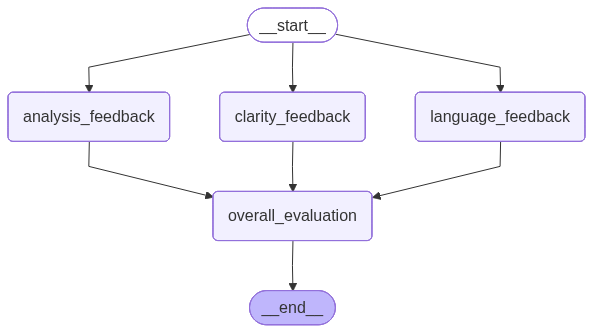

In [48]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
print(final_state)

{'essay': '\n# Climate Change\n\nClimate change is one of the most pressing challenges facing humanity today. It refers to long-term changes in global temperature and weather patterns, primarily caused by human activities such as burning fossil fuels, deforestation, and industrialization. These activities increase the concentration of greenhouse gases in the atmosphere, leading to global warming.\n\nThe impacts of climate change are visible across the world. Rising temperatures, melting glaciers, frequent heat waves, floods, droughts, and cyclones threaten ecosystems and human livelihoods. Agriculture, water resources, biodiversity, and public health are particularly vulnerable. Developing countries like India face greater risks due to their dependence on climate-sensitive sectors and large populations.\n\nAddressing climate change requires collective action at the global, national, and individual levels. International agreements such as the Paris Agreement aim to limit global temperat

In [50]:
final_state['analysis_feedback']

'The essay provides a good overview of the topic of climate change, including its causes, impacts, and potential solutions. However, the analysis is not particularly deep, with many points being stated without significant elaboration or supporting evidence. The essay could benefit from more nuanced discussions of the complexities of climate change, as well as more specific examples and data to illustrate the points being made. Additionally, the essay could explore potential counterarguments or alternative perspectives to strengthen its argument. Overall, the essay demonstrates a good understanding of the topic, but could be improved with more detailed analysis and critical thinking.'

In [52]:
final_state['overall_feedback']

"**Overall Feedback**\n\nThe essay demonstrates a strong foundation in terms of language quality, clarity of thought, and overall structure. The writer effectively conveys their ideas in a clear and concise manner, making it easy to follow and understand. The use of formal and objective language, proper grammar, and effective vocabulary enhances the essay's credibility and suitability for an academic or professional audience.\n\nHowever, there are areas that require improvement to take the essay to the next level. The analysis, while providing a good overview of the topic, lacks depth and nuance. The writer could benefit from providing more detailed explanations, supporting evidence, and specific examples to illustrate their points. Additionally, exploring potential counterarguments and alternative perspectives would strengthen the argument and demonstrate a higher level of critical thinking.\n\nTo further improve, the writer could focus on developing more complex sentence structures a

In [51]:
final_state['avg_score']

7.333333333333333

In [53]:
final_state

{'essay': '\n# Climate Change\n\nClimate change is one of the most pressing challenges facing humanity today. It refers to long-term changes in global temperature and weather patterns, primarily caused by human activities such as burning fossil fuels, deforestation, and industrialization. These activities increase the concentration of greenhouse gases in the atmosphere, leading to global warming.\n\nThe impacts of climate change are visible across the world. Rising temperatures, melting glaciers, frequent heat waves, floods, droughts, and cyclones threaten ecosystems and human livelihoods. Agriculture, water resources, biodiversity, and public health are particularly vulnerable. Developing countries like India face greater risks due to their dependence on climate-sensitive sectors and large populations.\n\nAddressing climate change requires collective action at the global, national, and individual levels. International agreements such as the Paris Agreement aim to limit global temperat